# Integrer Bybanen
Vi måler akselerasjonen til bybanen ved hjelp av mobiltelefon og bruker integrasjon til å finne toppfart og avstand mellom to bybanestopp.

https://github.com/LektorB/R2/blob/main/Integrer%20bybanen.docx

<Axes: xlabel='Time (s)'>

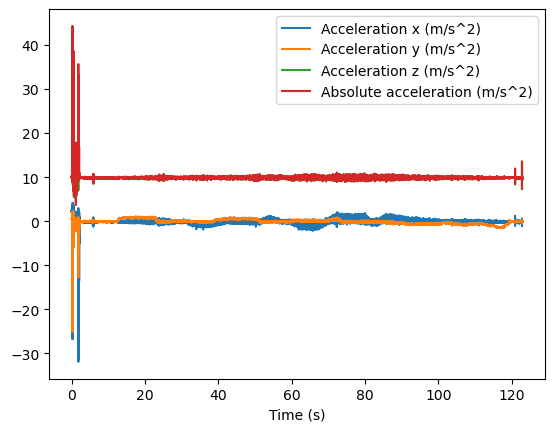

In [44]:
# Vi leser inn og blir kjent med datasettet:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

URL = 'https://raw.githubusercontent.com/LektorB/R2/refs/heads/main/BybaneData.csv'

data=pd.read_csv(URL)
# Plotter hele datarammen
data.plot(x='Time (s)')

In [45]:
print(data.head())
print(f"\nSer at dt = {0.013124-0.010686:.6f}") 
print('Det er nyttig å vite når vi skal gjøre utplukk av datasettet')

   Time (s)  Acceleration x (m/s^2)  Acceleration y (m/s^2)  \
0  0.010686                2.229812                0.668495   
1  0.013124                2.155634                0.754636   
2  0.015562                2.165205                0.800399   
3  0.018000                2.256133                0.824327   
4  0.020438                2.349752                0.833899   

   Acceleration z (m/s^2)  Absolute acceleration (m/s^2)  
0                9.847063                      10.118478  
1                9.847063                      10.108456  
2                9.815957                      10.083738  
3                9.756136                      10.047479  
4                9.727423                      10.041886  

Ser at dt = 0.002438
Det er nyttig å vite når vi skal gjøre utplukk av datasettet


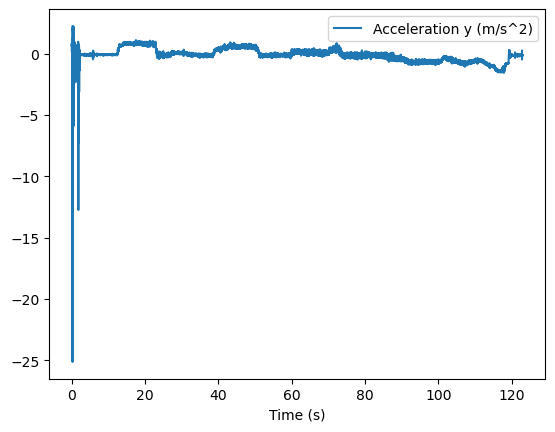

In [46]:
#Plotter bare y-retning som er den vi er inteeresert i 
data.plot(x='Time (s)',y='Acceleration y (m/s^2)');


In [16]:
# Ser av plottet at det er ca 2.5 skunder med støy i starten
# dette er meg som splår på og plasserer telefonen.

print('hvor mange datapunkter tilsvarer 2.5 sekund?')
print(2.5/0.002438)

hvor mange datapunkter tilsvarer 2.5 sekund?
1025.4306808859722


Vi er fornøyd med det utplukket


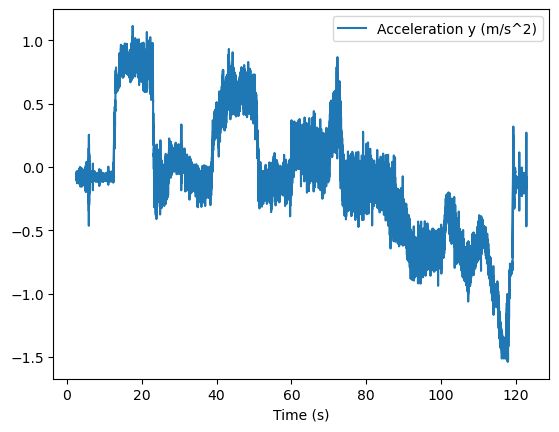

In [48]:
# plotter datasettet fra det 1000 punktet og framover
data[1000:].plot(x='Time (s)',y='Acceleration y (m/s^2)')
print('Vi er fornøyd med det utplukket')

In [20]:
# Siden vi er fornøyd med endringen lager vi et nytt sett
# med kun de delene vi bruker: 
data2 = data[1000:]

In [49]:
# For oss som ikke er drevne dataanalister er det letter å jobbe med 
# numpy sine arrayer enn datarammer
yaks = np.array(data2['Acceleration y (m/s^2)'])
tid = np.array(data2['Time (s)'])

Vi ser at akselerometereret ikke viser null selv om bybanen står i ro


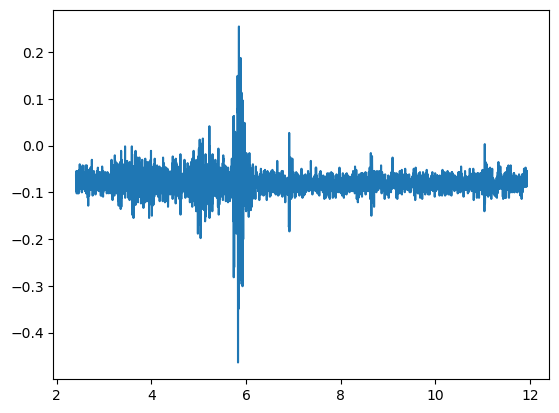

In [50]:
# Vi ska kalirerer og trenger noen sekunder hvor bybanen står i ro, 
# Vi prøver oss fram og sjekker med et plott

plt.plot(tid[:4000],yaks[:4000])
print('Vi ser at akselerometereret ikke viser null selv om bybanen står i ro')

Nå er vi fornøyd siden målingene svinger om null 
Vi er klar til å integrere!


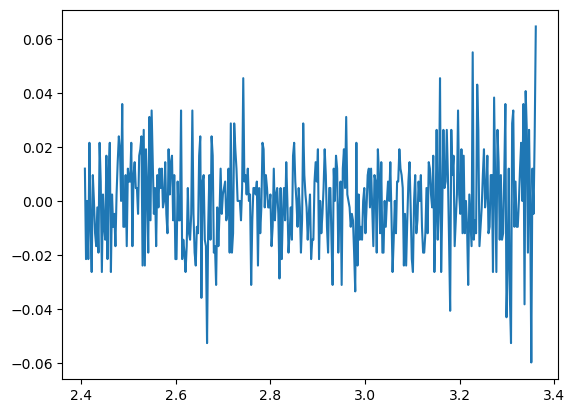

In [51]:
# kalibrerer og skjekker 
yaks = yaks-np.mean(yaks[:400]) # trekker fra gjennomsnittsmålinge fra alle målinger
plt.plot(tid[:400],yaks[:400])
print('Nå er vi fornøyd siden målingene svinger om null \nVi er klar til å integrere!')

Maksfart i følge mine målinger: 69.9 km/h


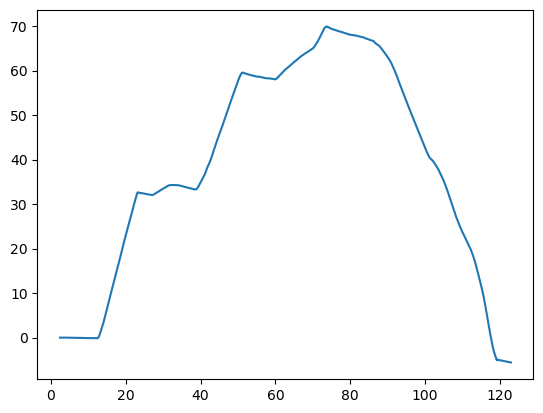

In [52]:
# Nå kan vi integrere:
dt = tid[1] - tid[0]
fartsendring = yaks*dt # vi regner ut alle små fartsendriger
fart=np.cumsum(fartsendring) # Vi summerer løpende og får fart som en funksjon av tid.

fart_km_h=fart*3.6
print(f'Maksfart i følge mine målinger: {np.max(fart_km_h):.1f} km/h')
plt.plot(tid,fart_km_h);

Bybaneturen var på 1313 m, i følge våre beregninger


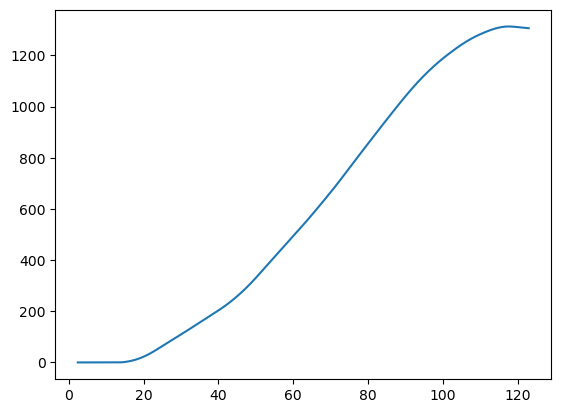

In [53]:
#Integrerer en gang til for å finne strekning

delta_s = fart*dt
strekning = np.cumsum(delta_s)
plt.plot(tid,strekning)
print(f'Bybaneturen var på {np.max(strekning):.0f} m, i følge våre beregninger')